Data setelah full-pemrosesan:
   age  sex     bmi  children  smoker   charges  region_northwest  \
0   19    0  27.900         0       1  9.734236             False   
1   18    1  33.770         1       0  7.453882             False   
2   28    1  33.000         3       0  8.400763             False   
3   33    1  22.705         0       0  9.998137              True   
4   32    1  28.880         0       0  8.260455              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

--- Proses tuning hyperparameter sedang berjalan... ---
Fitting 3 folds for each of 30 candidates, totalling 90 fits

--- Parameter terbaik dari tuning ---
{'colsample_bytree': np.float64(0.9248708096267587), 'learning_rate': np.float64(0.04182534743350856), 'max_depth': 3, 'n_estimators': 125, 'random_state': 42

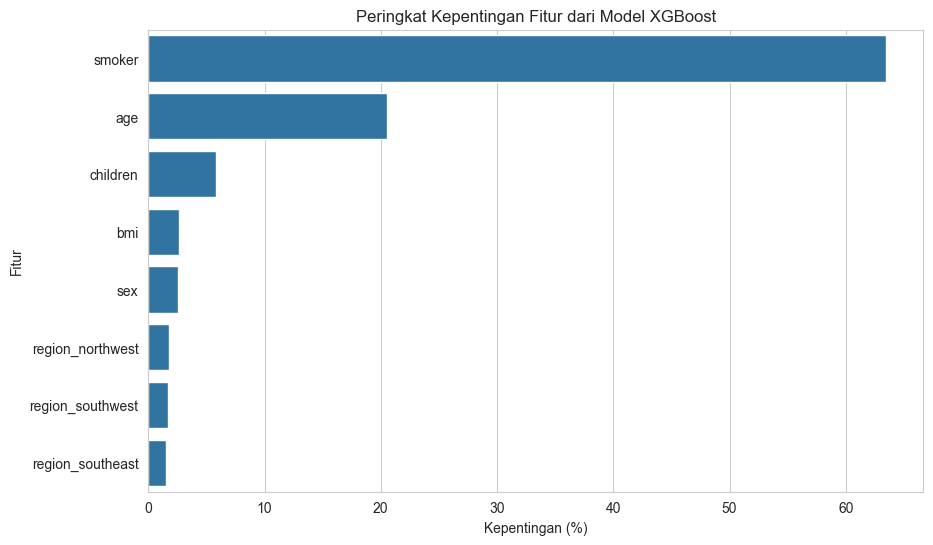


Fitur terpilih untuk model final (Top 5): ['smoker', 'age', 'children', 'bmi', 'sex']

--- EVALUASI MODEL DENGAN BERBAGAI JUMLAH FITUR TERATAS ---
Top 3 features → R² = 0.7286
Top 5 features → R² = 0.8800
Top 7 features → R² = 0.8808
Top 9 features → R² = 0.8827

--- HASIL FULL TESTING (EVALUASI AKHIR MODEL XGBOOST) ---
Final R-squared (R²): 0.8820
Final Root Mean Squared Error (RMSE): $4,280.94
Final Mean Absolute Error (MAE): $1,840.99

--- HASIL EVALUASI SETELAH FEATURE SELECTION ---
Final R-squared (R²): 0.8800
Final Root Mean Squared Error (RMSE): $4,316.84
Final Mean Absolute Error (MAE): $1,907.55


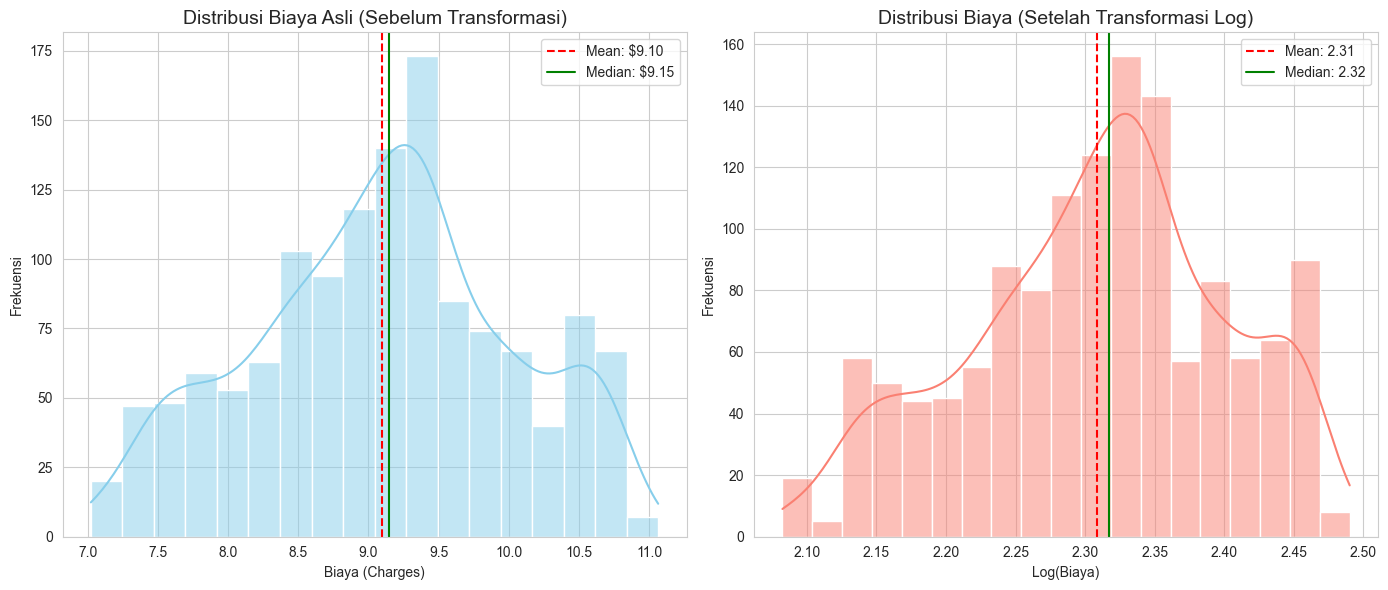


--- TABEL PERBANDINGAN ACTUAL VS PREDICTED ---
      Actual Charges  Predicted Charges        Error
764       9095.06825        9749.072266  -654.004016
887       5272.17580        5760.338379  -488.162579
890      29330.98315       27283.216797  2047.766353
1293      9301.89355        9706.420898  -404.527348
259      33750.29180       31792.761719  1957.530081
1312      4536.25900        5759.223145 -1222.964145
899       2117.33885        2318.697998  -201.359148
752      14210.53595       13588.745117   621.790833
1286      3732.62510        3865.342041  -132.716941
707      10264.44210       10991.105469  -726.663369
780      18259.21600       18426.035156  -166.819156
567       7256.72310        7771.627441  -514.904341
76        3947.41310        4785.659180  -838.246080
265      46151.12450       43376.335938  2774.788563
901      48673.55880       48354.027344   319.531456
893      44202.65360       44054.054688   148.598912
650       9800.88820       10941.236328 -1140.34812

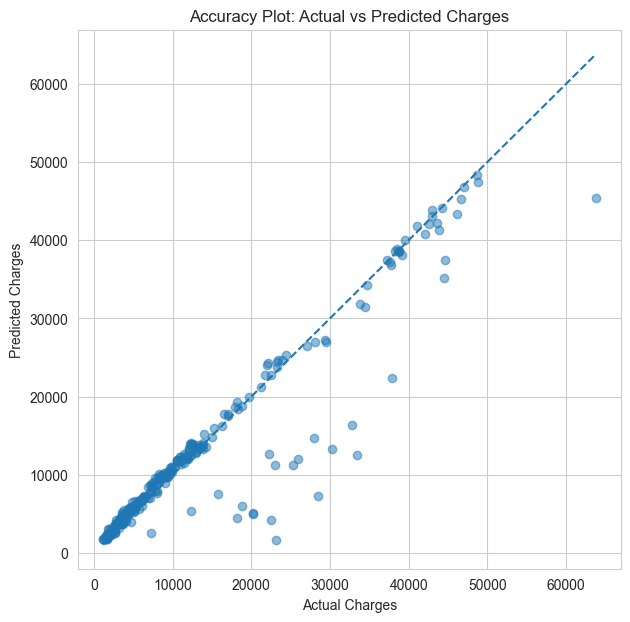

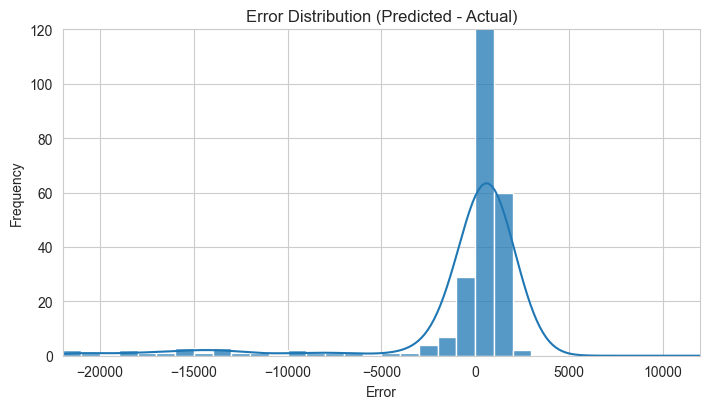

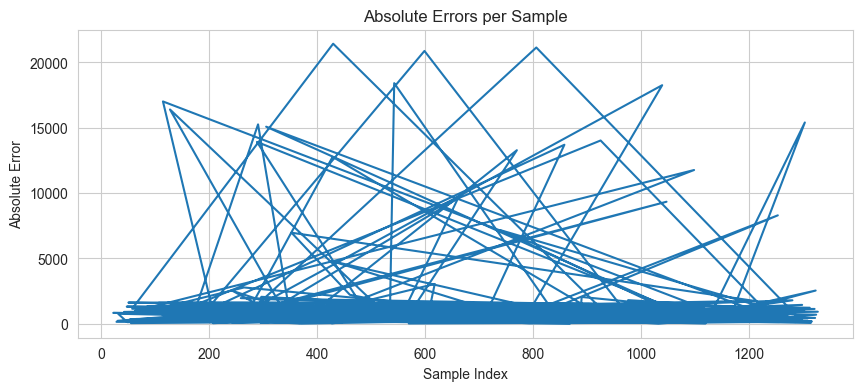

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import uniform, randint
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/audreychristabelleh/Downloads/machine learning/project/fullinsurance.csv', sep=';')

df['sex'] = df['sex'].apply(lambda x: 1 if x == 'male' else 0)
df['smoker'] = df['smoker'].apply(lambda x: 1 if x == 'yes' else 0) 
df = pd.get_dummies(df, columns=['region'], drop_first=True)

df['charges'] = np.log1p(df['charges'])

print("Data setelah full-pemrosesan:")
print(df.head())

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_dist = {
    'n_estimators': randint(120, 180), 
    'max_depth': randint(3, 5),
    'learning_rate': uniform(0.03, 0.04), 
    'subsample': uniform(0.8, 0.2),
    'colsample_bytree': uniform(0.8, 0.2), 
    'random_state': [42] 
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror') 

random_search = RandomizedSearchCV(
    estimator=xgb_model, 
    param_distributions=param_dist, 
    n_iter=30, 
    scoring='r2', 
    cv=3, 
    verbose=1, 
    random_state=42, 
    n_jobs=-1 
)

print("\n--- Proses tuning hyperparameter sedang berjalan... ---")
random_search.fit(X_train, y_train) 
best_params_from_tuning = random_search.best_params_ 

print("\n--- Parameter terbaik dari tuning ---")
print(best_params_from_tuning)

model_final_xgb = xgb.XGBRegressor(**best_params_from_tuning) 
model_final_xgb.fit(X_train, y_train) 
print("\nModel final (XGBoost) telah berhasil dilatih dengan parameter terbaik.")

y_pred_log_final_xgb = model_final_xgb.predict(X_test)
y_pred_final_xgb = np.expm1(y_pred_log_final_xgb)
y_test_actual = np.expm1(y_test)

r2_final_xgb = r2_score(y_test_actual, y_pred_final_xgb)
rmse_final_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_final_xgb))
mae_final_xgb = mean_absolute_error(y_test_actual, y_pred_final_xgb)

print("\n--- HASIL FULL TESTING (EVALUASI AKHIR MODEL XGBOOST) ---")
print(f"Final R-squared (R²): {r2_final_xgb:.4f}")
print(f"Final Root Mean Squared Error (RMSE): ${rmse_final_xgb:,.2f}")
print(f"Final Mean Absolute Error (MAE): ${mae_final_xgb:,.2f}")

importances_xgb = model_final_xgb.feature_importances_
feature_importance_df_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)
feature_importance_df_xgb['Importance'] = feature_importance_df_xgb['Importance'] * 100

print("\n--- Peringkat Kepentingan Fitur (Feature Importance) dari XGBoost ---")
print(feature_importance_df_xgb)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb)
plt.title('Peringkat Kepentingan Fitur dari Model XGBoost')
plt.xlabel('Kepentingan (%)')
plt.ylabel('Fitur')
plt.show()

top_n = 5
top_features = feature_importance_df_xgb['Feature'].head(top_n).tolist()
print(f"\nFitur terpilih untuk model final (Top {top_n}):", top_features)

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

model_selected_xgb = xgb.XGBRegressor(**best_params_from_tuning)
model_selected_xgb.fit(X_train_selected, y_train)

y_pred_log_selected = model_selected_xgb.predict(X_test_selected)
y_pred_selected = np.expm1(y_pred_log_selected)
y_test_actual = np.expm1(y_test)

r2_selected = r2_score(y_test_actual, y_pred_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test_actual, y_pred_selected))
mae_selected = mean_absolute_error(y_test_actual, y_pred_selected)

print("\n--- EVALUASI MODEL DENGAN BERBAGAI JUMLAH FITUR TERATAS ---")
for n in [3, 5, 7, 9]: 
    top_features = feature_importance_df_xgb['Feature'].head(n).tolist()
    model = xgb.XGBRegressor(**best_params_from_tuning)
    model.fit(X_train[top_features], y_train)
    y_pred = np.expm1(model.predict(X_test[top_features]))
    r2 = r2_score(np.expm1(y_test), y_pred)
    print(f"Top {n} features → R² = {r2:.4f}") 

print("\n--- HASIL FULL TESTING (EVALUASI AKHIR MODEL XGBOOST) ---")
print(f"Final R-squared (R²): {r2_final_xgb:.4f}")
print(f"Final Root Mean Squared Error (RMSE): ${rmse_final_xgb:,.2f}")
print(f"Final Mean Absolute Error (MAE): ${mae_final_xgb:,.2f}")

print("\n--- HASIL EVALUASI SETELAH FEATURE SELECTION ---")
print(f"Final R-squared (R²): {r2_selected:.4f}")
print(f"Final Root Mean Squared Error (RMSE): ${rmse_selected:,.2f}")
print(f"Final Mean Absolute Error (MAE): ${mae_selected:,.2f}")

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['charges'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Biaya Asli (Sebelum Transformasi)', fontsize=14)
axes[0].set_xlabel('Biaya (Charges)')
axes[0].set_ylabel('Frekuensi')

mean_before = df['charges'].mean()
median_before = df['charges'].median()
axes[0].axvline(mean_before, color='red', linestyle='--', label=f'Mean: ${mean_before:,.2f}')
axes[0].axvline(median_before, color='green', linestyle='-', label=f'Median: ${median_before:,.2f}')
axes[0].legend()

log_charges = np.log1p(df['charges'])
sns.histplot(log_charges, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Biaya (Setelah Transformasi Log)', fontsize=14)
axes[1].set_xlabel('Log(Biaya)')
axes[1].set_ylabel('Frekuensi')

mean_after = log_charges.mean()
median_after = log_charges.median()
axes[1].axvline(mean_after, color='red', linestyle='--', label=f'Mean: {mean_after:.2f}')
axes[1].axvline(median_after, color='green', linestyle='-', label=f'Median: {median_after:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Actual Charges': y_test_actual,
    'Predicted Charges': y_pred_final_xgb,
    'Error': y_test_actual - y_pred_final_xgb
})

print("\n--- TABEL PERBANDINGAN ACTUAL VS PREDICTED ---")
print(comparison_df.head(20)) 

plt.figure(figsize=(7,7))
plt.scatter(y_test_actual, y_pred_final_xgb, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         linestyle='--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Accuracy Plot: Actual vs Predicted Charges")
plt.show()

# Error: Predicted - Actual
comparison_df["Error"] = comparison_df["Predicted Charges"] - comparison_df["Actual Charges"]
err = comparison_df["Error"].replace([np.inf, -np.inf], np.nan).dropna()

x_min, x_max = -22000, 12000
y_min, y_max = 0, 120

bin_width = 1000
bins = np.arange(x_min, x_max + bin_width, bin_width)

plt.figure(figsize=(7.2, 4.2))
sns.histplot(
    err,
    bins=bins,
    kde=True,
    stat="count",
    edgecolor="white",
    alpha=0.75,
    kde_kws={"cut": 50, "clip": (x_min, x_max)}   # <-- ini kuncinya biar garis lanjut
)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(np.arange(-20000, 10001, 5000))
plt.yticks(np.arange(0, 121, 20))

plt.title("Error Distribution (Predicted - Actual)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,4))
plt.plot(np.abs(errors))
plt.title("Absolute Errors per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Absolute Error")
plt.show()



In [2]:
pip install shap


  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.6/555.6 kB 1.3 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 1.7 MB/s  0:00:22m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 1.3 MB/s  0:00:02 eta 0:00:010m
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [shap]5/7 [numba]te]
Note: you may need to restart the kernel to use updated packages.



SHAP Values berhasil dihitung.


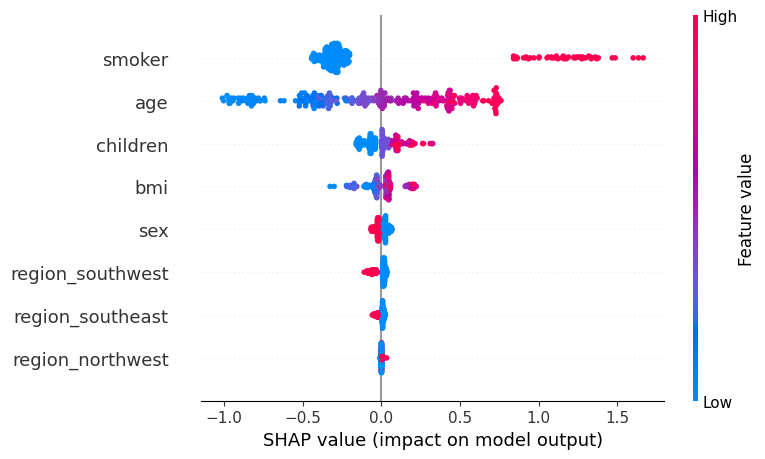

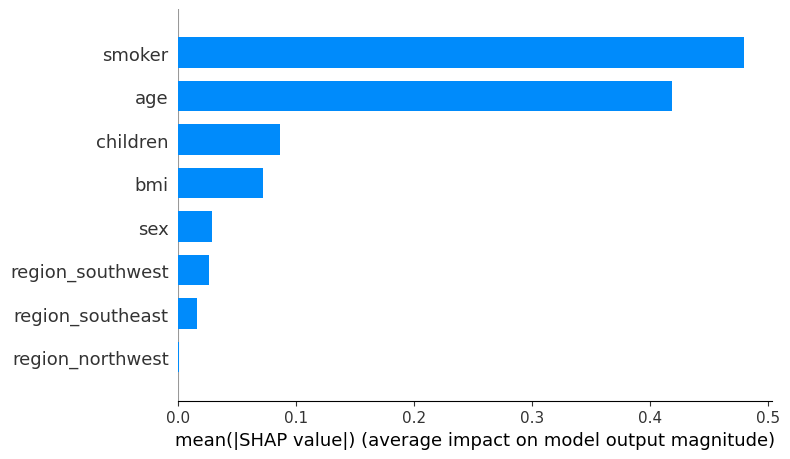

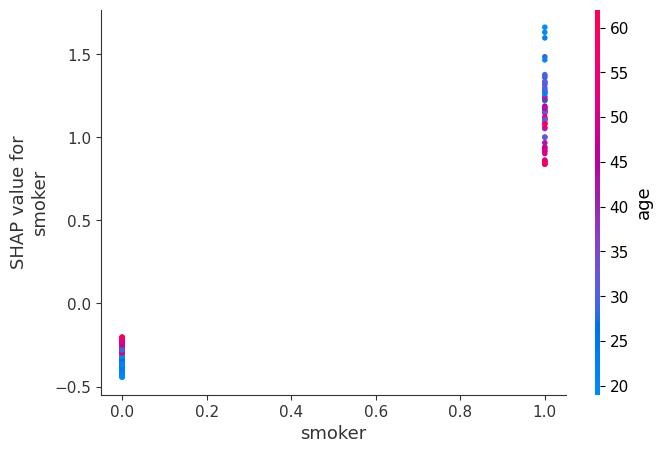

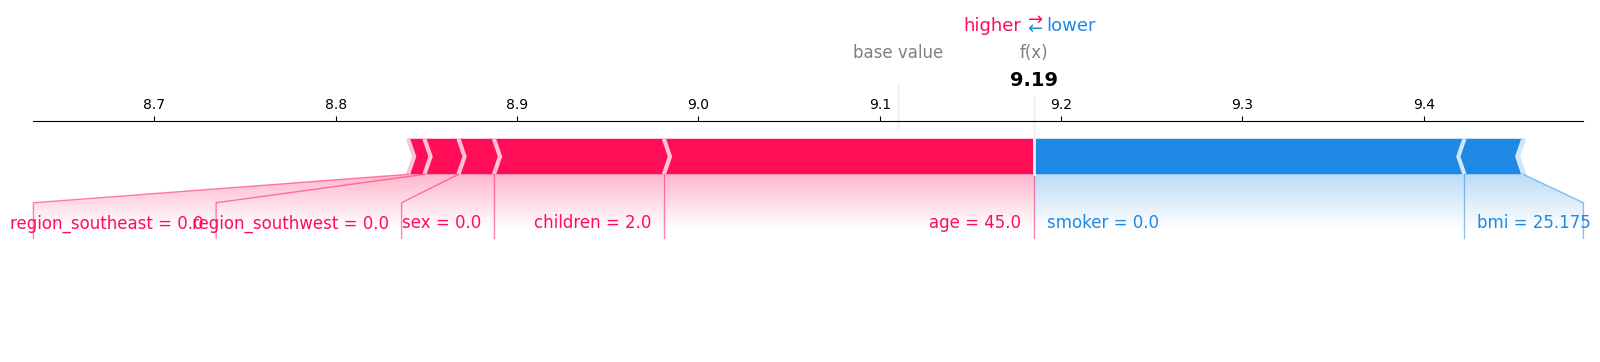

In [ ]:
import shap

explainer = shap.TreeExplainer(model_final_xgb)

shap_values = explainer.shap_values(X_test)

print("\nSHAP Values berhasil dihitung.")

# 1. SUMMARY PLOT

shap.summary_plot(shap_values, X_test, plot_type="dot")
plt.show()

# 2. BAR PLOT (Mean Absolute SHAP values)

shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

# 3. DEPENDENCE PLOT (Pengaruh 1 fitur)
top_feature = feature_importance_df_xgb['Feature'].iloc[0]

shap.dependence_plot(top_feature, shap_values, X_test)
plt.show()

# 4. EXPLANATION UNTUK SATU OBSERVASI

# Pilih 1 sampel dari X_test
index_sample = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[index_sample, :],
    X_test.iloc[index_sample, :],
    matplotlib=True
)
plt.show()


In [4]:
# Hitung rata-rata kontribusi absolut tiap fitur (Mean |SHAP value|)
shap_abs_mean = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP Value|": shap_abs_mean
}).sort_values(by="Mean |SHAP Value|", ascending=False)

print("\n=== Rata-rata Kontribusi SHAP per Fitur (Semakin besar → semakin berpengaruh) ===")
print(shap_importance_df)



=== Rata-rata Kontribusi SHAP per Fitur (Semakin besar → semakin berpengaruh) ===
            Feature  Mean |SHAP Value|
4            smoker           0.479420
0               age           0.418925
3          children           0.086121
2               bmi           0.071608
1               sex           0.028201
7  region_southwest           0.025820
6  region_southeast           0.015517
5  region_northwest           0.000931


In [5]:
# Pilih satu sampel
i = 0  
sample = X_test.iloc[i]

print("\n=== Penjelasan SHAP untuk 1 sampel (sample index 0) ===")
contrib_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": sample.values,
    "SHAP Contribution": shap_values[i]
}).sort_values(by="SHAP Contribution", ascending=False)

print(contrib_df)



=== Penjelasan SHAP untuk 1 sampel (sample index 0) ===
            Feature Feature Value  SHAP Contribution
0               age            45           0.204078
3          children             2           0.093719
1               sex             0           0.019539
7  region_southwest         False           0.018760
6  region_southeast         False           0.009041
5  region_northwest         False          -0.000490
2               bmi        25.175          -0.032473
4            smoker             0          -0.237338


In [6]:
print("\n=== Penjelasan Otomatis dari SHAP (Global) ===")
for idx, row in shap_importance_df.iterrows():
    f = row["Feature"]
    v = row["Mean |SHAP Value|"]
    print(f"- {f} memiliki kontribusi rata-rata {v:.4f} terhadap prediksi model.")

print("\n=== Penjelasan Otomatis untuk Satu Sampel ===")
top_pos = contrib_df.head(3)
top_neg = contrib_df.tail(3)

print("Fitur yang PALING MENINGKATKAN prediksi biaya:")
for i, r in top_pos.iterrows():
    print(f"- {r['Feature']} (nilai {r['Feature Value']}) meningkatkan prediksi sebesar {r['SHAP Contribution']:.4f}")

print("\nFitur yang MENURUNKAN prediksi biaya:")
for i, r in top_neg.iterrows():
    print(f"- {r['Feature']} (nilai {r['Feature Value']}) menurunkan prediksi sebesar {r['SHAP Contribution']:.4f}")



=== Penjelasan Otomatis dari SHAP (Global) ===
- smoker memiliki kontribusi rata-rata 0.4794 terhadap prediksi model.
- age memiliki kontribusi rata-rata 0.4189 terhadap prediksi model.
- children memiliki kontribusi rata-rata 0.0861 terhadap prediksi model.
- bmi memiliki kontribusi rata-rata 0.0716 terhadap prediksi model.
- sex memiliki kontribusi rata-rata 0.0282 terhadap prediksi model.
- region_southwest memiliki kontribusi rata-rata 0.0258 terhadap prediksi model.
- region_southeast memiliki kontribusi rata-rata 0.0155 terhadap prediksi model.
- region_northwest memiliki kontribusi rata-rata 0.0009 terhadap prediksi model.

=== Penjelasan Otomatis untuk Satu Sampel ===
Fitur yang PALING MENINGKATKAN prediksi biaya:
- age (nilai 45) meningkatkan prediksi sebesar 0.2041
- children (nilai 2) meningkatkan prediksi sebesar 0.0937
- sex (nilai 0) meningkatkan prediksi sebesar 0.0195

Fitur yang MENURUNKAN prediksi biaya:
- region_northwest (nilai False) menurunkan prediksi sebesar -0

<Figure size 600x600 with 0 Axes>

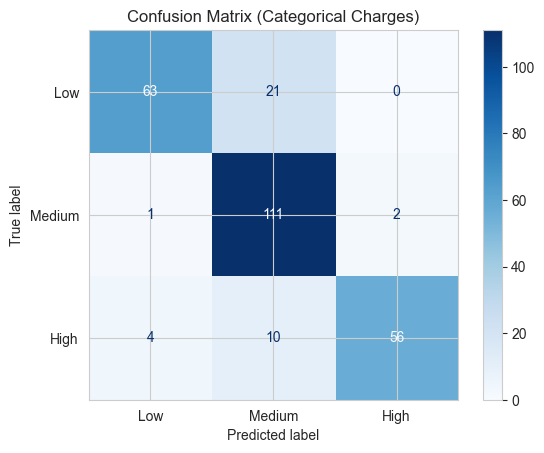

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Contoh: buat kategori charges
bins = [0, 5000, 15000, np.inf]  # rentang kategori
labels = ['Low', 'Medium', 'High']

# Ubah actual dan prediksi ke kategori
y_test_cat = pd.cut(y_test_actual, bins=bins, labels=labels)
y_pred_cat = pd.cut(y_pred_shap, bins=bins, labels=labels)

# Hitung confusion matrix
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Plot
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Categorical Charges)")
plt.show()
